<a href="https://colab.research.google.com/github/alminha021/DS-rcf/blob/main/vc_Segmenta%C3%A7ao_RCF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files

# a. Filtro Laplaciano (detecção de bordas)
laplaciano = np.array([
    [ 1, 1,  1],
    [ 1, -8, 1],
    [ 1, 1,  1]
])

#Filtro de retas horizontais
filtro_retah = np.array([
    [-1, -1, -1],
    [ 2,  2,  2],
    [-1, -1, -1]
])

#Filtro de retas +45°
filtro_retap45 = np.array([
    [ 2, -1, -1],
    [-1,  2, -1],
    [-1, -1,  2]
])

#Filtro de retas verticais
filtro_retav = np.array([
    [-1,  2, -1],
    [-1,  2, -1],
    [-1,  2, -1]
])

#Filtro de retas -45°
filtro_retan45 = np.array([
    [-1, -1,  2],
    [-1,  2, -1],
    [ 2, -1, -1]
])

#Filtro Sobel vertical
sobelv = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

#Filtro Sobel horizontal
sobelh = np.array([
    [-1,-2,-1],
    [ 0, 0, 0],
    [ 1, 2, 1]
])

#Filtro Sobel diagonal primaria
sobeldp = np.array([
    [ 0, 1, 2],
    [-1, 0, 1],
    [-2,-1, 0]
])

#Filtro Sobel diagonal secundaria
sobelds = np.array([
    [-2,-1, 0],
    [-1, 0, 1],
    [ 0, 1, 2]
])



In [ ]:
def correlacao2d(imagem, kernel):
    M, N = imagem.shape
    m, n = kernel.shape

    x1 = m // 2
    y1 = n // 2

    imagem_padded = np.pad(imagem, ((x1, x1), (y1, y1)), mode='constant')
    saida = np.zeros_like(imagem, dtype=np.float32)

    for x in range(M):
        for y in range(N):
            soma = 0.0
            for i in range(-x1, x1 + 1):
                for j in range(-y1, y1 + 1):
                    pixel = imagem_padded[x + i + x1, y + j + y1]
                    peso = kernel[i + x1, j + y1]
                    soma += peso * pixel
            saida[x, y] = soma

    return saida

In [ ]:
def exibir(imagem, titulo=''):
    plt.imshow(imagem, cmap='gray')
    plt.title(titulo)
    plt.show()

Saving jazzy.png to jazzy (2).png


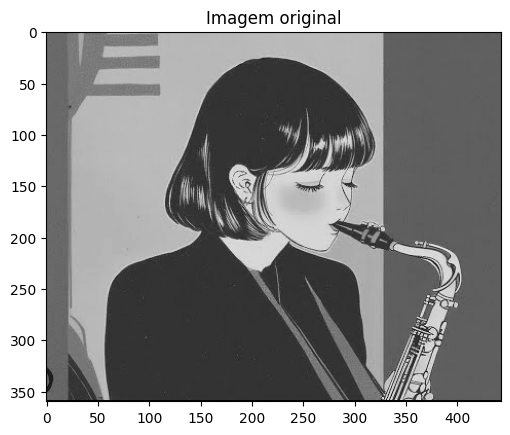

In [ ]:
# Carrega a imagem (coloque sua imagem em escala de cinza)
uploaded = files.upload()
for filename in uploaded.keys():
    img = cv2.imread(filename)
    break
image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def normalizar(img):
    img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    return img_norm.astype(np.uint8)

imagem = normalizar(image)

# Aplica cada filtro
# Laplaciano
img_lap = correlacao2d(imagem, laplaciano)

# 4 retas
img_retah = correlacao2d(imagem, filtro_retah)
img_retav = correlacao2d(imagem, filtro_retav)
img_retap45 = correlacao2d(imagem, filtro_retap45)
img_retan45 = correlacao2d(imagem, filtro_retan45)

# sobles
img_sobelv = correlacao2d(imagem, sobelv)
img_sobelh = correlacao2d(imagem, sobelh)
img_sobeldp = correlacao2d(imagem, sobeldp)
img_sobelds = correlacao2d(imagem, sobelds)

#EXIBIR
exibir(imagem, 'Imagem original')

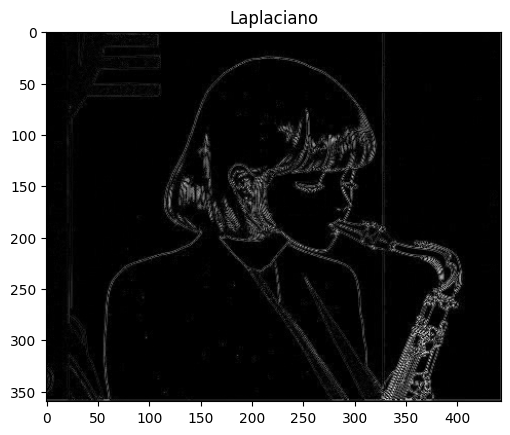

In [ ]:
# Laplaciano
img_lap_abs = np.abs(img_lap)
normalizar_img = normalizar(img_lap_abs)
exibir(normalizar_img, 'Laplaciano')
#exibir(img_lap, 'Filtro Laplaciano')

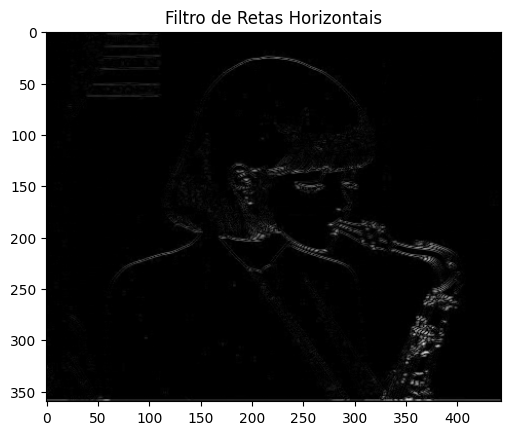

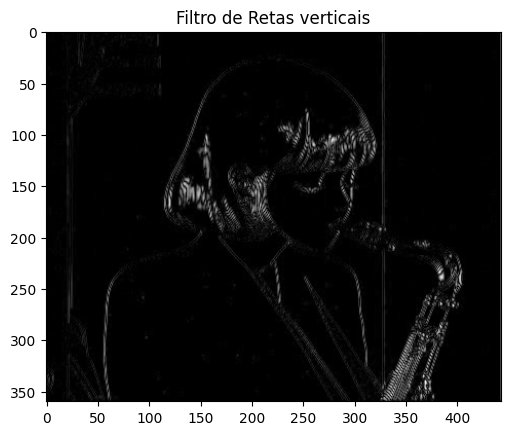

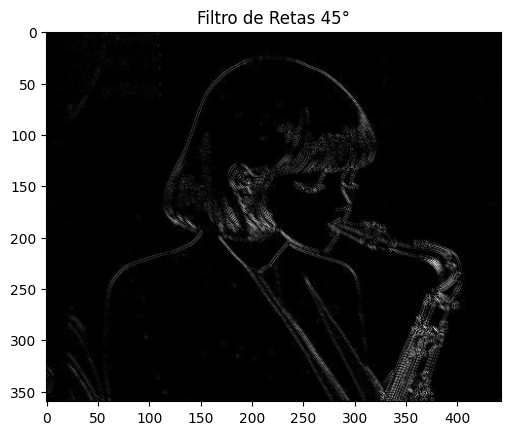

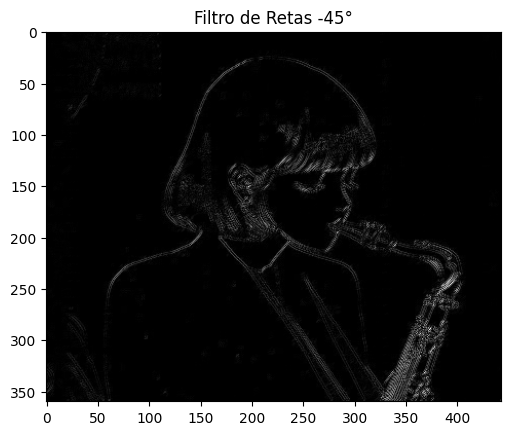

In [ ]:
# retas

img_lap_abs_retah = np.abs(img_retah)
normalizar_img_retah = normalizar(img_lap_abs_retah)

img_lap_abs_retav = np.abs(img_retav)
normalizar_img_retav = normalizar(img_lap_abs_retav)

img_lap_abs_retap45 = np.abs(img_retap45)
normalizar_img_retap45 = normalizar(img_lap_abs_retap45)

img_lap_abs_retan45 = np.abs(img_retan45)
normalizar_img_retan45 = normalizar(img_lap_abs_retan45)

exibir(normalizar_img_retah, 'Filtro de Retas Horizontais')
exibir(normalizar_img_retav, 'Filtro de Retas verticais')
exibir(normalizar_img_retap45, 'Filtro de Retas 45°')
exibir(normalizar_img_retan45, 'Filtro de Retas -45°')

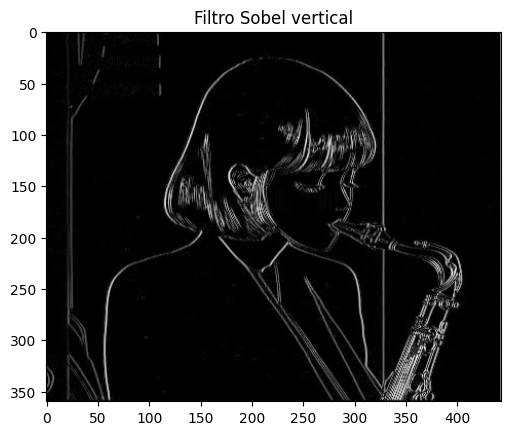

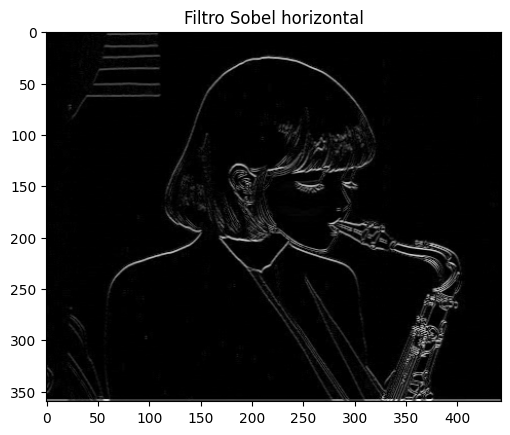

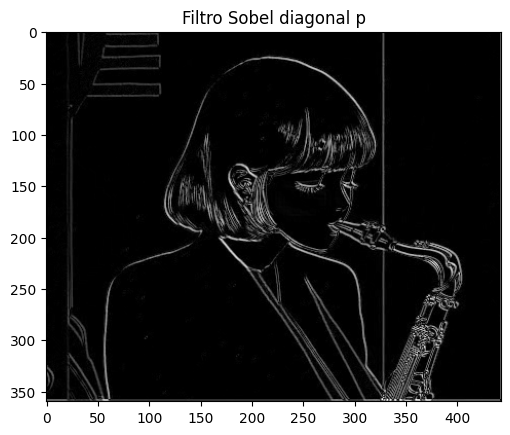

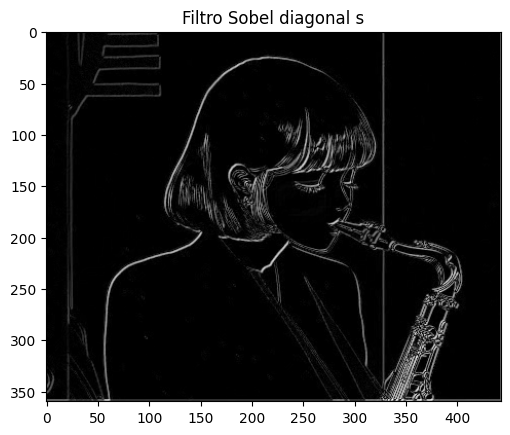

In [ ]:
# sobel
img_lap_abs_sobelv = np.abs(img_sobelv)
normalizar_img_sobelv = normalizar(img_lap_abs_sobelv)

img_lap_abs_sobelh = np.abs(img_sobelh)
normalizar_img_sobelh = normalizar(img_lap_abs_sobelh)

img_lap_abs_sobeldp = np.abs(img_sobeldp)
normalizar_img_sobeldp = normalizar(img_lap_abs_sobeldp)

img_lap_abs_sobelds = np.abs(img_sobelds)
normalizar_img_sobelds = normalizar(img_lap_abs_sobelds)


exibir(normalizar_img_sobelv, 'Filtro Sobel vertical')
exibir(normalizar_img_sobelh, 'Filtro Sobel horizontal')
exibir(normalizar_img_sobeldp, 'Filtro Sobel diagonal p')
exibir(normalizar_img_sobelds, 'Filtro Sobel diagonal s')

In [ ]:
def otsu(img):
    hist = np.bincount(img.ravel(), minlength=256)
    total = img.size

    prob = hist / total
    somatorio_total = np.dot(np.arange(256), prob)

    peso_a = 0.0
    media_a = 0.0

    var_max = 0.0
    limiar_otimo = 0

    for limiar in range(256):
        peso_a += prob[limiar]
        if peso_a == 0:
            continue

        peso_b = 1.0 - peso_a
        if peso_b == 0:
            break

        media_a += limiar * prob[limiar]
        media_a_norm = media_a / peso_a
        media_b_norm = (somatorio_total - media_a) / peso_b
        var_entre = peso_a * peso_b * (media_a_norm - media_b_norm) ** 2

        if var_entre > var_max:
            var_max = var_entre


    return limiar

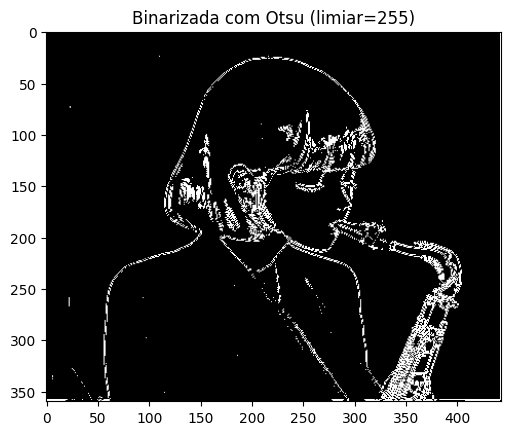

In [ ]:
# 1. Filtro Laplaciano
img_lap = correlacao2d(imagem, laplaciano)

# 2. Módulo absoluto (para evitar negativos)
img_lap_abs = np.abs(img_lap)

# 3. Normalização para 0-255
img_lap_norm = normalizar(img_lap_abs)

# 4. Aplica Otsu
thresh = otsu(img_lap_norm)
img_binarizada = (img_lap_abs > thresh).astype(np.uint8) * 255

# 5. Exibir
#exibir(img_lap_norm, 'Laplaciano Normalizado')
exibir(img_binarizada, f'Binarizada com Otsu (limiar={thresh})')

sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg



sgsg

